
========== STOCK DATA ==========
         Date     Stock   Sector  Price  Quantity
0  2026-08-01  RELIANCE   Energy   2450        20
1  2026-08-01       TCS       IT   3450        15
2  2026-08-01  HDFCBANK  Banking   1780        25
3  2026-08-01      INFY       IT   1620        20
4  2026-08-01       ITC     FMCG    470        30

Dataset Shape:
(35, 5)

========== DATA CLEANING ==========

Missing Values:
Date        0
Stock       0
Sector      0
Price       0
Quantity    0
dtype: int64

Duplicate Rows:
0

========== PROFIT / LOSS ==========
       Stock   Sector  Investment  Current_Value  Profit_Loss  Return_Percent
30  RELIANCE   Energy       49000          52200         3200        6.530612
31       TCS       IT       51750          54600         2850        5.507246
32  HDFCBANK  Banking       44500          46750         2250        5.056180
33      INFY       IT       32400          34400         2000        6.172840
34       ITC     FMCG       14100          14850          7

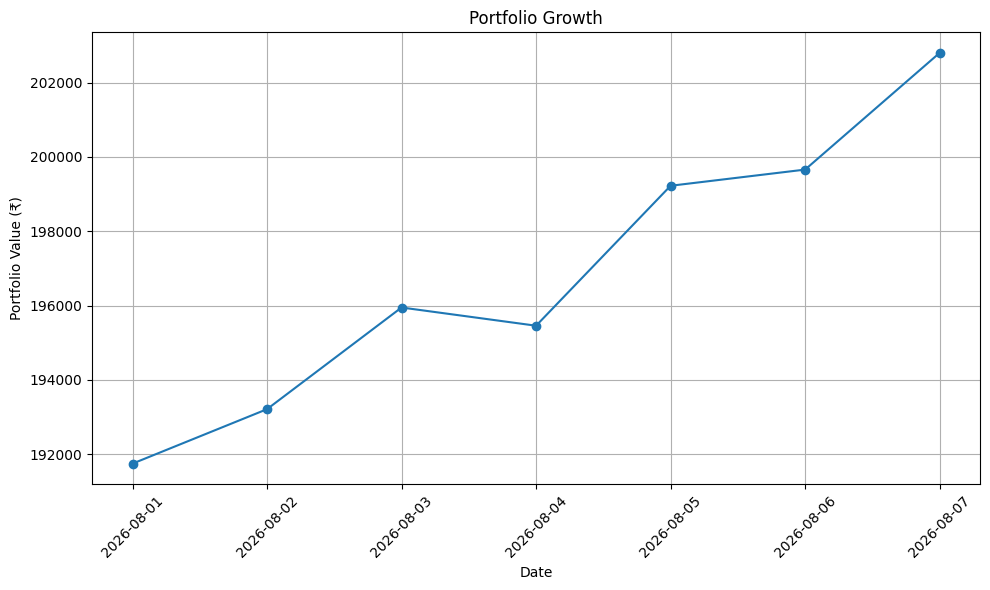


========== SECTOR-WISE INVESTMENT ==========
Sector
Banking    44500
Energy     49000
FMCG       14100
IT         84150
Name: Investment, dtype: int64


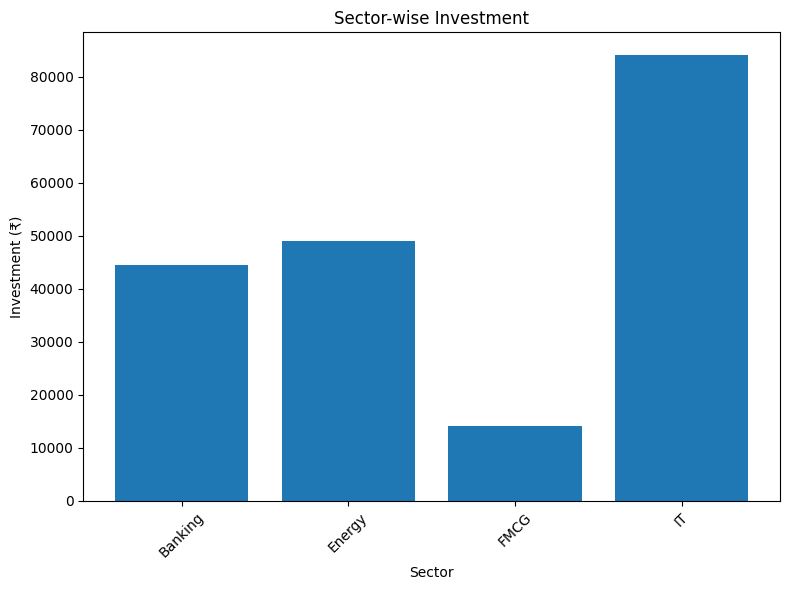


========== DAILY RETURN ==========
Date
2026-08-01     NaN
2026-08-02    0.76
2026-08-03    1.42
2026-08-04   -0.25
2026-08-05    1.93
2026-08-06    0.22
2026-08-07    1.57
Name: Current_Value, dtype: float64


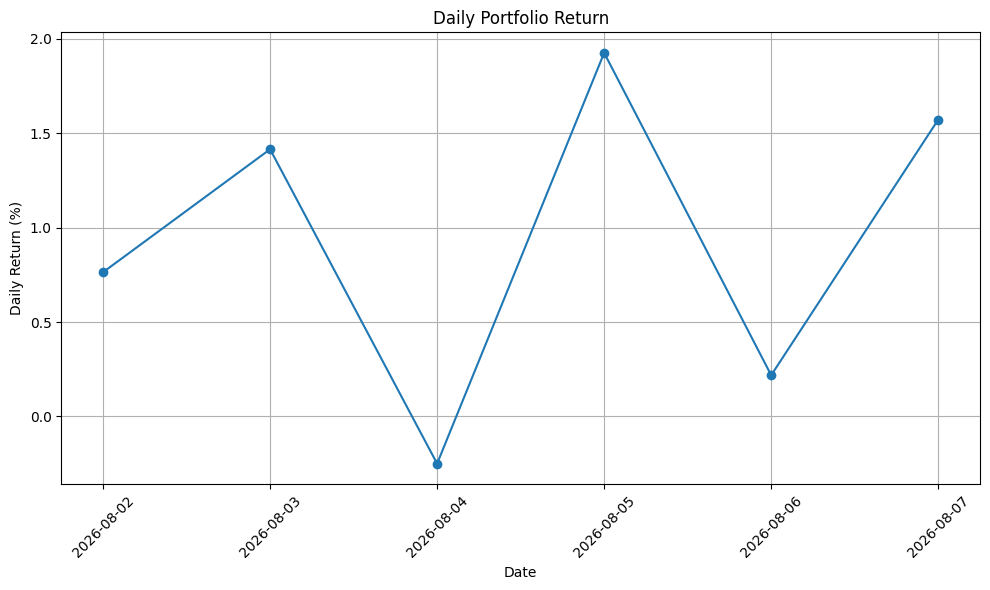


========== MOVING AVERAGE ==========
Date
2026-08-01          NaN
2026-08-02          NaN
2026-08-03    193638.33
2026-08-04    194875.00
2026-08-05    196878.33
2026-08-06    198115.00
2026-08-07    200561.67
Name: Current_Value, dtype: float64

Next Day Trend: Potential Upward Trend

✅ Portfolio report exported!
File: portfolio_report.csv

========== FINAL SUMMARY ==========
Total Stocks: 5
Total Investment: ₹ 191750
Current Value: ₹ 202800
Profit/Loss: ₹ 11050
Portfolio Return: 5.76 %
Best Stock: RELIANCE
Worst Stock: HDFCBANK
Next Day Trend: Potential Upward Trend

🎉 STOCK PORTFOLIO ANALYZER COMPLETED!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# 1. READ CSV DATA
# ==========================================

df = pd.read_csv("stock_market_data.csv")

print("\n========== STOCK DATA ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


# ==========================================
# 2. DATA CLEANING
# ==========================================

print("\n========== DATA CLEANING ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Make sure Price and Quantity are numeric
df["Price"] = pd.to_numeric(df["Price"])

df["Quantity"] = pd.to_numeric(df["Quantity"])


# ==========================================
# 3. PURCHASE PRICE
# ==========================================

# First available price is treated
# as purchase price

df["Purchase_Price"] = (
    df.groupby("Stock")["Price"]
    .transform("first")
)


# ==========================================
# 4. INVESTMENT
# ==========================================

df["Investment"] = (
    df["Purchase_Price"]
    * df["Quantity"]
)


# ==========================================
# 5. CURRENT VALUE
# ==========================================

df["Current_Value"] = (
    df["Price"]
    * df["Quantity"]
)


# ==========================================
# 6. PROFIT / LOSS
# ==========================================

df["Profit_Loss"] = (
    df["Current_Value"]
    - df["Investment"]
)


# ==========================================
# 7. RETURN %
# ==========================================

df["Return_Percent"] = (
    df["Profit_Loss"]
    / df["Investment"]
) * 100


print("\n========== PROFIT / LOSS ==========")

latest_date = df["Date"].max()

latest_data = df[
    df["Date"] == latest_date
].copy()

print(
    latest_data[
        [
            "Stock",
            "Sector",
            "Investment",
            "Current_Value",
            "Profit_Loss",
            "Return_Percent"
        ]
    ]
)


# ==========================================
# 8. BEST PERFORMING STOCK
# ==========================================

best_stock = latest_data.loc[
    latest_data["Return_Percent"].idxmax()
]

print("\n========== BEST PERFORMING STOCK ==========")

print(
    "Stock:",
    best_stock["Stock"]
)

print(
    "Return:",
    round(
        best_stock["Return_Percent"],
        2
    ),
    "%"
)


# ==========================================
# 9. WORST PERFORMING STOCK
# ==========================================

worst_stock = latest_data.loc[
    latest_data["Return_Percent"].idxmin()
]

print("\n========== WORST PERFORMING STOCK ==========")

print(
    "Stock:",
    worst_stock["Stock"]
)

print(
    "Return:",
    round(
        worst_stock["Return_Percent"],
        2
    ),
    "%"
)


# ==========================================
# 10. OVERALL PORTFOLIO RETURN
# ==========================================

total_investment = (
    latest_data["Investment"].sum()
)

total_current_value = (
    latest_data["Current_Value"].sum()
)

total_profit_loss = (
    total_current_value
    - total_investment
)

overall_return = (
    total_profit_loss
    / total_investment
) * 100


print("\n========== PORTFOLIO SUMMARY ==========")

print(
    "Total Investment: ₹",
    round(total_investment, 2)
)

print(
    "Current Portfolio Value: ₹",
    round(total_current_value, 2)
)

print(
    "Total Profit/Loss: ₹",
    round(total_profit_loss, 2)
)

print(
    "Overall Portfolio Return:",
    round(overall_return, 2),
    "%"
)


# ==========================================
# 11. PORTFOLIO GROWTH
# ==========================================

daily_portfolio = (
    df.groupby("Date")["Current_Value"]
    .sum()
)


plt.figure(figsize=(10, 6))

plt.plot(
    daily_portfolio.index,
    daily_portfolio.values,
    marker="o"
)

plt.title("Portfolio Growth")

plt.xlabel("Date")

plt.ylabel("Portfolio Value (₹)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "portfolio_growth.png"
)

plt.show()


# ==========================================
# 12. SECTOR-WISE INVESTMENT
# ==========================================

sector_investment = (
    latest_data
    .groupby("Sector")["Investment"]
    .sum()
)


print("\n========== SECTOR-WISE INVESTMENT ==========")

print(sector_investment)


plt.figure(figsize=(8, 6))

plt.bar(
    sector_investment.index,
    sector_investment.values
)

plt.title(
    "Sector-wise Investment"
)

plt.xlabel("Sector")

plt.ylabel("Investment (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "sector_investment.png"
)

plt.show()


# ==========================================
# 13. DAILY RETURN ANALYSIS
# ==========================================

daily_return = (
    daily_portfolio
    .pct_change()
    * 100
)


print("\n========== DAILY RETURN ==========")

print(
    daily_return.round(2)
)


plt.figure(figsize=(10, 6))

plt.plot(
    daily_return.index,
    daily_return.values,
    marker="o"
)

plt.title(
    "Daily Portfolio Return"
)

plt.xlabel("Date")

plt.ylabel("Daily Return (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "daily_return.png"
)

plt.show()


# ==========================================
# 14. MOVING AVERAGE
# ==========================================

print("\n========== MOVING AVERAGE ==========")

moving_average = (
    daily_portfolio
    .rolling(window=3)
    .mean()
)

print(
    moving_average.round(2)
)


# ==========================================
# 15. NEXT DAY TREND
# ==========================================

last_value = daily_portfolio.iloc[-1]

last_moving_average = moving_average.iloc[-1]


if last_value > last_moving_average:

    next_day_trend = "Potential Upward Trend"

elif last_value < last_moving_average:

    next_day_trend = "Potential Downward Trend"

else:

    next_day_trend = "Potential Sideways Trend"


print(
    "\nNext Day Trend:",
    next_day_trend
)


# ==========================================
# 16. EXPORT REPORT
# ==========================================

portfolio_report = latest_data[
    [
        "Stock",
        "Sector",
        "Quantity",
        "Purchase_Price",
        "Price",
        "Investment",
        "Current_Value",
        "Profit_Loss",
        "Return_Percent"
    ]
].copy()


portfolio_report.to_csv(
    "portfolio_report.csv",
    index=False
)


print(
    "\n✅ Portfolio report exported!"
)

print(
    "File: portfolio_report.csv"
)


# ==========================================
# 17. FINAL SUMMARY
# ==========================================

print("\n========== FINAL SUMMARY ==========")

print(
    "Total Stocks:",
    latest_data["Stock"].nunique()
)

print(
    "Total Investment: ₹",
    round(total_investment, 2)
)

print(
    "Current Value: ₹",
    round(total_current_value, 2)
)

print(
    "Profit/Loss: ₹",
    round(total_profit_loss, 2)
)

print(
    "Portfolio Return:",
    round(overall_return, 2),
    "%"
)

print(
    "Best Stock:",
    best_stock["Stock"]
)

print(
    "Worst Stock:",
    worst_stock["Stock"]
)

print(
    "Next Day Trend:",
    next_day_trend
)

print(
    "\n🎉 STOCK PORTFOLIO ANALYZER COMPLETED!"
)